In [1]:
intro_images_path='./Images/Intro_images/'
edge_images_path='./Images/Edge_images/'
seg_images_path='./Images/Seg_images/'
feature_images_path='./Images/Feature_images/'
output_images_path='./Images/Output_images/'

# Visión por Computador

**Grao en Intelixencia Artificial**

Curso 2025-26


<img src="./Logotipo_Solo.png" width=200/>



## Detectores e descritores de características

- Selección de rexións invariantes á escala
- Detector de Harris
- Detector de manchas
- Descritores de características e correspondencia
- Exercicio: detección e correspondencia de características, aliñamento de imaxes

https://docs.opencv.org/4.2.0/db/d27/tutorial_py_table_of_contents_feature2d.html


### Detector de Harris 



In [2]:
%matplotlib inline
from matplotlib import pyplot as plt
from scipy.ndimage import rotate, gaussian_filter1d, gaussian_filter
import numpy as np
import cv2

**Función para supresión de non máximos**

In [3]:
def nonmax_suppression(harris_resp, thr, halfwidth=2):
    # Outputs:
    # 1) cornersy: list with row coordinates of identified corner pixels.
    # 2) cornersx: list with respective column coordinates of identified corner pixels.
    # Elements from the two lists with the same index must correspond to the same corner.
    
    cornersy = []
    cornersx = []
    h, w = im.shape[:2]
    for y in range(halfwidth, h-halfwidth):
        for x in range(halfwidth, w-halfwidth):
            if harris_resp[y, x] < thr:
                continue

            is_max = True
            for ny in range(y-halfwidth, y+halfwidth+1):
                for nx in range(x-halfwidth, x+halfwidth+1):
                    is_max = is_max and (harris_resp[ny, nx] <= harris_resp[y, x])
            if not is_max:
                continue
            cornersx.append(x)
            cornersy.append(y)

    return cornersy, cornersx

**Código para calcular a medida de esquina**

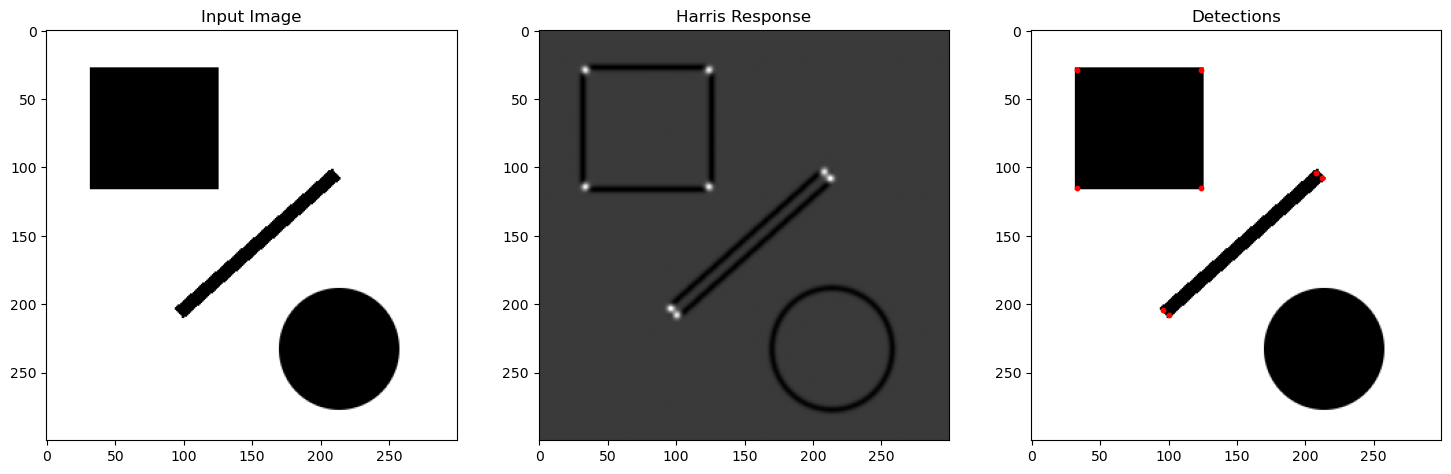

In [4]:
# Define parameters
sigma_w = 2.0
sigma_d = 2.0
kappa = 0.04
rot_angle = 0
thresh = 800

# Read the image
im = cv2.imread(feature_images_path+'CircleLineRect.png', 0)
im = im.astype('float')

# Rotation of the image
if rot_angle != 0:
    im = rotate(im, rot_angle)

# Implement Harris corners
# Useful functions: gaussian_filter1d, gaussian_filter
I_x = gaussian_filter1d(im, sigma_d, order=0, axis=0)
I_x = gaussian_filter1d(I_x, sigma_d, order=1, axis=1)

I_y = gaussian_filter1d(im, sigma_d, order=0, axis=1)
I_y = gaussian_filter1d(I_y, sigma_d, order=1, axis=0)

A_11 = I_x ** 2
A_22 = I_y ** 2
A_12 = I_x * I_y

A_11 = gaussian_filter(A_11, sigma_w)
A_22 = gaussian_filter(A_22, sigma_w)
A_12 = gaussian_filter(A_12, sigma_w)

det = np.multiply(A_11, A_22) - np.multiply(A_12, A_12)
trc = A_11 + A_22
H = det - kappa * trc * trc
corn = nonmax_suppression(H,thresh,2)


# Plotting of results
plt.close("all")
plt.ion()
f, ax_arr = plt.subplots(1, 3, figsize=(18, 16))
ax_arr[0].set_title("Input Image")
ax_arr[1].set_title("Harris Response")
ax_arr[2].set_title("Detections")
ax_arr[0].imshow(im, cmap='gray')
ax_arr[1].imshow(H, cmap='gray')
ax_arr[2].imshow(im, cmap='gray')
ax_arr[2].scatter(x=corn[1], y=corn[0], c='r', s=10)


https://docs.opencv.org/4.2.0/dc/d0d/tutorial_py_features_harris.html

OpenCV ten a seguinte función para este propósito:

**dst=cv2.cornerHarris(src, blockSize, ksize)**

- src - Imaxe de entrada, debe ser en escala de grises e de tipo float32.
- blockSize - É o tamaño da veciñanza considerada para a detección de esquinas.
- ksize - Parámetro de apertura da derivada de Sobel utilizada.
- k - Parámetro libre do detector de Harris.

 **Exercicio: Xoga cos parámetros para ver o efecto na detección.**

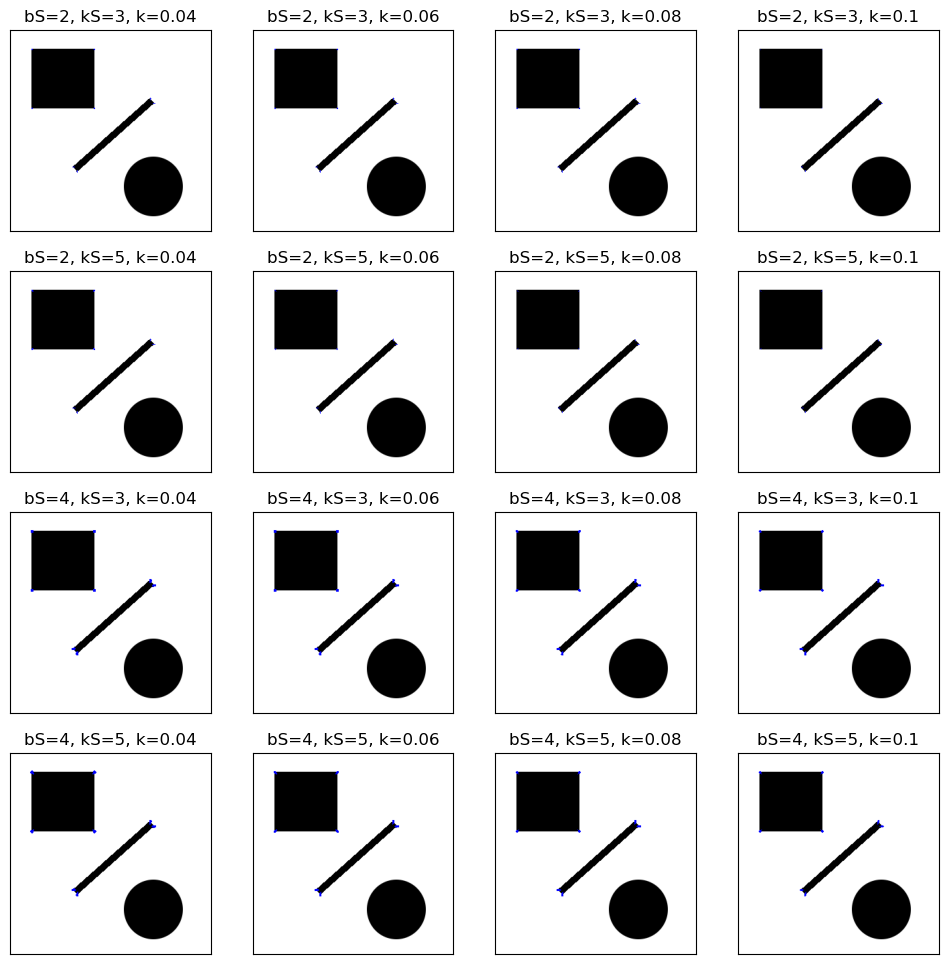

In [15]:
filename = feature_images_path+'CircleLineRect.png'
img = cv2.imread(filename)
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

fig, axs = plt.subplots(4, 4, figsize=(12, 12))
axs = axs.flatten()

# creamos un diccionario con los parámetros a probar de la función cornerHarris
#blockSize: es el tamaño del vecindario considerado para la detección de esquinas
#ksize: es el tamaño del filtro Sobel utilizado para calcular las derivadas de la imagen
#k: es la constante libre en la ecuación de Harris, que afecta la sensibilidad de la detección de esquinas

param_dict = [
    {'blockSize':2, 'ksize':3, 'k':0.04},
    {'blockSize':2, 'ksize':3, 'k':0.06},
    {'blockSize':2, 'ksize':3, 'k':0.08},
    {'blockSize':2, 'ksize':3, 'k':0.1},
    {'blockSize':2, 'ksize':5, 'k':0.04},
    {'blockSize':2, 'ksize':5, 'k':0.06},
    {'blockSize':2, 'ksize':5, 'k':0.08},
    {'blockSize':2, 'ksize':5, 'k':0.1},
    {'blockSize':4, 'ksize':3, 'k':0.04},
    {'blockSize':4, 'ksize':3, 'k':0.06},
    {'blockSize':4, 'ksize':3, 'k':0.08},
    {'blockSize':4, 'ksize':3, 'k':0.1},
    {'blockSize':4, 'ksize':5, 'k':0.04},
    {'blockSize':4, 'ksize':5, 'k':0.06},
    {'blockSize':4, 'ksize':5, 'k':0.08},
    {'blockSize':4, 'ksize':5, 'k':0.1}
]

for i, params in enumerate(param_dict):
    dst = cv2.cornerHarris(gray,params['blockSize'],params['ksize'],params['k'])
    #result is dilated to easy visualization, not important
    #dst = cv2.dilate(dst,None)

    # Threshold for an optimal value, it may vary depending on the image.
    corners=img.copy()
    corners[dst>0.001*dst.max()]=[0,0,255]

    axs[i].imshow(corners)
    axs[i].set_title(f"bS={params['blockSize']}, kS={params['ksize']}, k={params['k']}")
    axs[i].set_xticks([]),axs[i].set_yticks([])

Usando **cv2.threshold()** en combinación coa función **cv2.connectedComponentsWithStats()**, podes recuperar a localización dos puntos de Harris máis visibles.

cv2.connectedComponentsWithStats() devolve a seguinte información:

    O cadro delimitador do compoñente conectado
    A área (en píxeles) do compoñente
    As coordenadas centroide/central (x, y) do compoñente

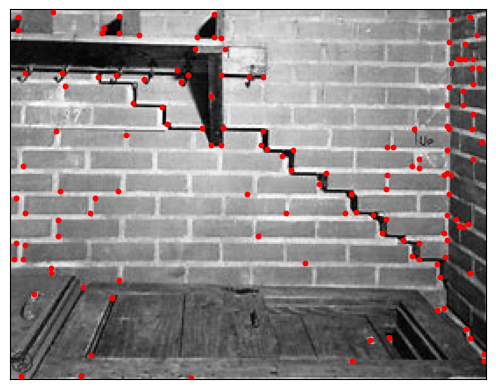

[array([[135, 105],
       [ 24,   1],
       [116,   2],
       [ 62,   3],
       [251,   5],
       [262,   4],
       [  4,   4],
       [  4,  11],
       [ 53,  10],
       [ 52,  13],
       [ 62,  13],
       [ 73,  14],
       [106,  15],
       [116,  15],
       [266,  14],
       [120,  16],
       [250,  18],
       [259,  19],
       [105,  22],
       [122,  22],
       [251,  30],
       [255,  28],
       [257,  28],
       [259,  28],
       [264,  28],
       [ 29,  36],
       [136,  38],
       [  8,  36],
       [ 60,  37],
       [ 76,  39],
       [263,  33],
       [267,  33],
       [ 50,  38],
       [ 95,  34],
       [120,  37],
       [ 97,  41],
       [101,  37],
       [144,  38],
       [264,  42],
       [ 31,  43],
       [250,  44],
       [114,  49],
       [258,  46],
       [ 70,  53],
       [249,  54],
       [ 86,  55],
       [258,  54],
       [264,  59],
       [ 89,  65],
       [109,  67],
       [121,  67],
       [230,  68],
       [249

In [24]:
filename = feature_images_path+'bricks_2.jpg'
img = cv2.imread(filename)
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

dst = cv2.cornerHarris(gray,3,3,0.04)

ret, dst = cv2.threshold(dst,0.01*dst.max(),255,0)
dst = np.uint8(dst)
# find centroids
ret, labels, stats, centroids = cv2.connectedComponentsWithStats(dst)
corn=centroids.astype(int)


plt.imshow(img)
plt.scatter(x=corn[:,0], y=corn[:,1], c='r', s=10)
plt.xticks([]),plt.yticks([])
plt.show()

print ([corn])

### Detector de manchas

OpenCV ofrece unha forma cómoda de detectar manchas e filtralas segundo diferentes características.
A clase **SimpleBlobDetector** implementa un algoritmo sinxelo para extraer manchas dunha imaxe:
- Converte a imaxe de orixe en imaxe binaria mediante un limiar con varios limiares desde *minThreshold* (incluído) ata *maxThreshold* (exclusivo) co paso *thresholdStep*.
- Extrae compoñentes conectados atopando contornos e os seus centros.
- Agrupa os centros polas súas coordenadas. Os centros próximos forman un grupo que corresponde a unha mancha, que se controla co parámetro *minDistBetweenBlobs*.
- A partir dos grupos, estima os centros finais das manchas e os seus raios e devolve como localizacións e tamaños de puntos clave.

Esta clase realiza varias filtracións das manchas devolvidas. Debes definir *filterBy* en verdadeiro/falso para activar/desactivar a filtración correspondente. Filtracións dispoñibles:
- Por cor: compara a intensidade do centro dunha mancha con *blobColor*. Se difiren, a mancha fíltrase. Usa blobColor = 0 para extraer manchas escuras e blobColor = 255 para extraer manchas claras.
- Por área: devolve manchas con áreas entre *minArea* (inclusive) e *maxArea* (exclusive).
- Por circularidade: filtra as manchas pola súa circularidade (4∗π∗Área/(perímetro∗perímetro) entre *minCircularity* (incluído) e *maxCircularity* (excluído).
- Pola relación entre a inercia mínima e a inercia máxima: as manchas extraídas teñen esta relación entre *minInertiaRatio* (incluído) e *maxInertiaRatio* (excluído).
- Por convexidade: devolve as manchas cunha convexidade (área/área da envolvente convexa da mancha) entre *minConvexity* (incluído) e *maxConvexity* (excluído).

Os valores predeterminados dos parámetros axústanse para extraer manchas circulares escuras.

In [ ]:
import cv2
import numpy as np;
from matplotlib import pyplot as plt
 
im = cv2.imread(feature_images_path+"fishes.jpg", cv2.IMREAD_GRAYSCALE) #"corunha.jpg", cv2.IMREAD_GRAYSCALE)
 
# Set up the detector with default parameters.
detector = cv2.SimpleBlobDetector_create()

# Set up the detector with specific parameters.
params = cv2.SimpleBlobDetector_Params()
params.filterByColor=True #Filter by Color
params.blobColor=0 #255
params.filterByArea = True # Filter by Area.
params.minArea = 100#20
params.maxArea = 1000 #4000
params.filterByCircularity = True #False # Filter by Circularity
params.minCircularity = 0.5
params.filterByConvexity = True #False # Filter by Convexity
params.minConvexity = 0.8
params.filterByInertia = False # Filter by Inertia
#params.minInertiaRatio = 0.8
params.minDistBetweenBlobs = 20 # Distance Between Blobs

# Set up the detector with specific parameters.
detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(im) # Detect blobs.

# Draw detected blobs as red circles.
# cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS ensures the size of the circle corresponds to the size of blob
im_with_keypoints = cv2.drawKeypoints(im, keypoints, np.array([]), (0,0,255), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
 
plt.imshow(im_with_keypoints), plt.title("Keypoints")
plt.xticks([]),plt.yticks([])
plt.show()

---
---
### EXERCICIO 3.1 (x.x puntos): Detección de blobs

Usa o detector de blobs para detectar a bóla na imaxe black-trap-rock.jpg (feature_images_path. Escolle os parámetros máis convenientes.

---
---

In [ ]:
#SOLUCIÓN AQUÍ

---
---
### Extracción de características de imaxes ORB

https://docs.opencv.org/4.2.0/d1/d89/tutorial_py_orb.html
https://docs.opencv.org/4.x/db/d95/classcv_1_1ORB.html

Este algoritmo presentouse como unha alternativa eficiente a SIFT ou SURF en custo de computación e rendemento de correspondencia.
Temos que crear un obxecto ORB coa función **cv2.ORB_create()**, que ten varios parámetros opcionais. Os máis útiles son:

**retval=cv2.ORB_create([, nFeatures[, scaleFactor[, nlevels[, edgeThreshold[, firstLevel[, WTA_K[, scoreType[, patchSize[, fastThreshold]]]]]]]])**

- nFeatures - denota o número máximo de características a conservar (por defecto 500).
- scaleFactor, nlevels - parámetros multiescala, 1,2 e 8 por defecto.
- patchSize - tamaño da zona empregada polo descritor BRIEF orientado, 31 por defecto.
- edgeThreshold - tamaño do bordo onde non se detectan as características. Debería coincidir aproximadamente co parámetro *patchSize*, 31 por defecto.

**A continuación móstrase un código sinxelo que mostra o uso de ORB:**

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

img = cv2.imread(seg_images_path+'hotel.jpg',0)
# Initiate detector
orb = cv2.ORB_create(nfeatures=5000)
# find the keypoints with ORB
kp = orb.detect(img,None)
# compute the descriptors with ORB
kp, des = orb.compute(img, kp)

# draw only keypoints location, not size and orientation
img2 = cv2.drawKeypoints(img, kp, None,color=(0,255,0), flags=0)
plt.imshow(img2)
plt.xticks([]),plt.yticks([])
plt.show()

### Correspondencia de características:

A correspondencia de forza bruta toma o descritor dunha característica do primeiro conxunto e compáraa con todas as outras características do segundo conxunto usando algún cálculo de distancia. Devolve a coincidencia máis próxima.

Primeiro temos que crear o obxecto BFMatcher usando **cv2.BFMatcher()**. Toma dous parámetros opcionais:

**retval=cv.BFMatcher_create([, normType[, crossCheck]])**

- normType - medición de distancia que se usará. Por defecto, é cv2.NORM_L2, pero para descritores baseados en cadeas binarias como ORB, debería usarse cv2.NORM_HAMMING. Se ORB usa VTA_K == 3 ou 4, debería usarse cv2.NORM_HAMMING2.

- crossCheck - booleano, falso por defecto. Se é verdadeiro, o comparador devolve só aquelas coincidencias co valor (i,j) de xeito que o i-ésimo descritor do conxunto A teña o j-ésimo descritor do conxunto B como a mellor coincidencia e viceversa.

Dous métodos importantes desta clase son **BFMatcher.match()** e **BFMatcher.knnMatch()**. O primeiro devolve a mellor coincidencia. O segundo método devolve as k mellores coincidencias onde k é especificado polo usuario.

Do mesmo xeito que cv2.drawKeypoints() debuxa puntos clave, **cv2.drawMatches()** debuxa as coincidencias. Apila dúas imaxes horizontalmente e debuxa liñas desde a primeira imaxe ata a segunda imaxe mostrando as mellores coincidencias.

**cv2.drawMatchesKnn()** debuxa as k mellores coincidencias. Se k=2, debuxará dúas liñas de coincidencia para cada punto clave. Polo tanto, temos que pasar unha máscara se queremos debuxala selectivamente.

Aquí veremos un exemplo sinxelo de como emparellar características entre dúas imaxes. Neste caso, temos unha imaxe de consulta e unha imaxe de proba. Tentaremos atopar a primeira na segunda usando a coincidencia de características.

In [ ]:
import numpy as np 
import cv2 
from matplotlib import pyplot as plt 


img1 = cv2.imread(feature_images_path+'houses_l.jpg',0) # query image 
img2 = cv2.imread(feature_images_path+'houses_r.jpg',0) # test image 

# Initiate detector 
orb = cv2.ORB_create(nfeatures=5000) 

# find the keypoints and descriptors 
kp1, des1 = orb.detectAndCompute(img1,None) 
kp2, des2 = orb.detectAndCompute(img2,None) 

# create BFMatcher object 
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True) 
# Match descriptors. 
matches = bf.match(des1,des2) 
# Sort them in ascending order of their distance. 
matches = sorted(matches, key = lambda x:x.distance) 

NUM_MATCHES=100

X_1 = []
X_2 = []
for i in range(NUM_MATCHES) :
    X_1.append([kp1[matches[i].queryIdx].pt[0], kp1[matches[i].queryIdx].pt[1]])
    X_2.append([kp2[matches[i].trainIdx].pt[0], kp2[matches[i].trainIdx].pt[1]])
X_1 = np.array(X_1)
X_2 = np.array(X_2)

#----------------------------------Display-------------------------------------------------------
# create an visualization on the matched on an image
match_image = cv2.drawMatches(img1,kp1,img2,kp2,matches[:100], img2, flags=2)

plt.figure(figsize=(40,20))
plt.subplot(221)
plt.imshow(img1, 'gray')
plt.plot(X_1[:,0], X_1[:,1], 'bo')
plt.subplot(222)
plt.imshow(img2, 'gray')
plt.plot(X_2[:,0], X_2[:,1], 'ro')
plt.subplot(223)
plt.imshow(match_image);
plt.axis('off')
plt.show() 

## Exercicio de aliñamento de imaxes

O aliñamento (ou rexistro) de imaxes é a técnica de deformar unha imaxe (ou ás veces ambas as imaxes) para que as características das dúas imaxes se aliñen perfectamente.

Nalgunhas aplicacións médicas, pódense tomar varias exploracións dun tecido en momentos lixeiramente diferentes e as imaxes rexístranse para ver a evolución no tempo. Pero a aplicación máis interesante do aliñamento de imaxes é quizais a creación de panoramas.

En xeral, o aliñamento 3D require información de profundidade. Non obstante, cando as dúas imaxes se toman xirando a cámara arredor do seu eixe óptico (como no caso dos panoramas), podemos usar o código seguinte para aliñar dúas vistas da escena.

A función **cv2.warpPerspective()** aplica unha transformación de perspectiva a unha imaxe:

**dst=cv2.warpPerspective(src, h, dsize)**

- src - imaxe de entrada.
- dst - imaxe de saída que ten o tamaño dsize e o mesmo tipo que src .
- h - homografía (matriz de transformación 3×3).
- Dsize - tamaño da imaxe de saída.

**Aquí presentamos un exemplo para dúas vistas dunha escena e buscamos a transformación da perspectiva:**

In [ ]:
import cv2 
import numpy as np 
from matplotlib import pyplot as plt 

MAX_FEATURES = 500 
GOOD_MATCH_PERCENT = 0.15

def alignImages(im1, im2): 

    # Convert images to grayscale 
    im1Gray = cv2.cvtColor(im1, cv2.COLOR_RGB2GRAY) 
    im2Gray = cv2.cvtColor(im2, cv2.COLOR_RGB2GRAY) 

    # Detect ORB features and compute descriptors. 
    orb = cv2.ORB_create(nfeatures=MAX_FEATURES) 
    kpts1, descriptors1 = orb.detectAndCompute(im1Gray,None) 
    kpts2, descriptors2 = orb.detectAndCompute(im2Gray,None) 

    # create BFMatcher object 
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True) 

    # Match features.    
    matches = matcher.match(descriptors1, descriptors2) 

    # Sort matches by score 
    matches = sorted(matches, key = lambda x:x.distance) 

    # Remove not so good matches 
    numGoodMatches = int(len(matches) * GOOD_MATCH_PERCENT) 
    matches = matches[:numGoodMatches] 

    # Draw top matches 
    imMatches=cv2.drawMatches(im1Gray,kpts1,im2Gray,kpts2, matches, None,flags=2) 

    plt.imshow(imMatches), plt.title('Matched Features'), plt.axis('off'),plt.show() 

    # cv2.imshow('Matched Features', imMatches) 
    # cv2.waitKey(0) 
    # cv2.destroyWindow('Matched Features') 
    # cv2.imwrite("matches.jpg", imMatches) 

    # Extract location of good matches 
    points1 = np.zeros((len(matches), 2), dtype=np.float32) 
    points2 = np.zeros((len(matches), 2), dtype=np.float32) 


    for i, match in enumerate(matches): 
        points1[i, :] = kpts1[match.queryIdx].pt 
        points2[i, :] = kpts2[match.trainIdx].pt 


    # Find homography 
    h, mask = cv2.findHomography(points1, points2, cv2.RANSAC) 

    # Use homography to align im1 with im2 
    height1, width1, _ = im1.shape 
    height2, width2, _ = im2.shape 

    #Aligned image im1Reg, using a 3x3 transformation matrix 
    im1Reg = cv2.warpPerspective(im1, h, (width1 + width2, height1)) 

    return im1Reg, h 


if __name__ == '__main__': 

    # Read reference image 
    right_Filename = feature_images_path+'houses_r.jpg' 
    print("Reading right image: ", right_Filename) 
    im_r = cv2.imread( right_Filename, cv2.IMREAD_COLOR)
    im_r=cv2.cvtColor(im_r, cv2.COLOR_BGR2RGB)

    # Read image to be aligned 
    left_Filename = feature_images_path+'houses_l.jpg'
    print("Reading left image: ", left_Filename);   
    im_l = cv2.imread(left_Filename, cv2.IMREAD_COLOR) 
    im_l=cv2.cvtColor(im_l, cv2.COLOR_BGR2RGB)

    plt.subplot(1,2,1)
    plt.imshow(im_l), plt.title("Left image")
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(im_r), plt.title("Right image")
    plt.axis('off')
    plt.show()
  


    print("Aligning images ...") 
    imReg, h = alignImages(im_r, im_l) 

    # Write aligned image to disk. 
    #outFilename = "aligned.jpg" 
    #print("Saving aligned image : ", outFilename); 
    #cv2.imwrite(outFilename, imReg) 
    plt.imshow(imReg), plt.title("Aligned image")
    plt.axis('off')
    plt.show()

    print("Estimated homography : \n",  h) 
    

### Extractor de características de imaxes SIFT

In [ ]:
import cv2
img = cv2.imread(feature_images_path+'hotel.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
sift = cv2.SIFT_create()
# Default values
# static Ptr<SIFT> cv::SIFT::create	(	int 	nfeatures = 0,
# int 	nOctaveLayers = 3,
# double 	contrastThreshold = 0.04,
# double 	edgeThreshold = 10,
# double 	sigma = 1.6
# )
#
# nfeatures: The number of best features to retain. The features are ranked by their scores
#           (measured in SIFT algorithm as the local contrast)
# nOctaveLayers: The number of layers in each octave. 3 is the value used in D. Lowe paper.
#           The number of octaves is dependent on the image resolution.
# contrastThreshold: The contrast threshold used to filter out weak features in semi-uniform
#           (low-contrast) regions. The larger the threshold, the less features are produced by
#           the detector.
# edgeThreshold: The threshold used to filter out edge-like features. Note that the its meaning
#           is different from the contrastThreshold, i.e. the larger the edgeThreshold, the less
#           features are filtered out (more features are retained).
# sigma: The sigma of the Gaussian applied to the input image at the octave #0. If your image is
#           captured with a weak camera with soft lenses, you might want to reduce the number.
keypoints, descriptors = sift.detectAndCompute(gray, None)
cv2.drawKeypoints(img, keypoints, img, (51, 163, 236), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.imshow(img), plt.title("Sift_keypoints")
plt.axis('off')
plt.show()

### Correspondencia de características

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

rigth_Filename = feature_images_path+'houses_r.jpg' 
print("Reading right image: ", rigth_Filename) 
im_r = cv2.imread( right_Filename, cv2.IMREAD_COLOR)
im_r=cv2.cvtColor(im_r, cv2.COLOR_BGR2RGB)

left_Filename = feature_images_path+'houses_l.jpg'
print("Reading left image: ", left_Filename);   
im_l = cv2.imread(left_Filename, cv2.IMREAD_COLOR) 
im_l=cv2.cvtColor(im_l, cv2.COLOR_BGR2RGB)


# Initiate SIFT detector
sift = cv2.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(im_r,None)
kp2, des2 = sift.detectAndCompute(im_l,None)

# BFMatcher with default params
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1,des2, k=2)

# Need to draw only good matches, so create a mask
matchesMask = [[0,0] for i in range(len(matches))]

# ratio test as per Lowe's paper
for i,(m,n) in enumerate(matches):
    if m.distance < 0.2*n.distance:
        matchesMask[i]=[1,0]
draw_params = dict(matchColor = (0,255,0),singlePointColor = (255,0,0),matchesMask = matchesMask,flags = 0)
img3 = cv2.drawMatchesKnn(im_r,kp1,im_l,kp2,matches,None,**draw_params)
plt.imshow(img3),plt.axis('off')
plt.show()

---
---
### EXERCICIO 3.2 (x.x puntos): Panorama

Agora, atopa a transformación afín entre view4.jpg e view5.jg (feature_images_path), transforma a segunda e logo úneas para crear unha panorama: pódese facer simplemente modificando a última parte da función
**alignImages()**.

height1, width1, _ = im_l.shape
height2, width2, _ = im_r.shape
Panorama = cv2.warpPerspective(im_r, h, (width1 + width2, height1))
Panorama[0:height2, 0:width1] = im_l

plt.imshow(Panorama), plt.title("Panorma")
plt.axis('off')
plt.show()

Escolle os parámetros máis convenientes.

---
---

In [ ]:

#SOLUCIÓN AQUÍ

---
---